# Analysis of Tipping Behavior

This project evaluates factors that influence tipping behavior in a restaurant setting.  
The goal is to understand how variables such as total bill amount, party size, and time of day relate to both tip amount and tip percentage.

Understanding tipping patterns can provide insight into customer behavior and help businesses anticipate revenue variability. It is also useful to servers and other resturaunts staff to predict pay.

## Data Setup

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv" #load data set
df = pd.read_csv(url)

df.head() #display first 5 

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
df.info() #check for missing values
df.describe() #descriptive stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Tip Amount Versus Bill Amount

The goal of this section is to determine the relationship between the tipped amount and the total amount of the bill. Does a larger bill correlate with a larger tip, or is the inverse true?

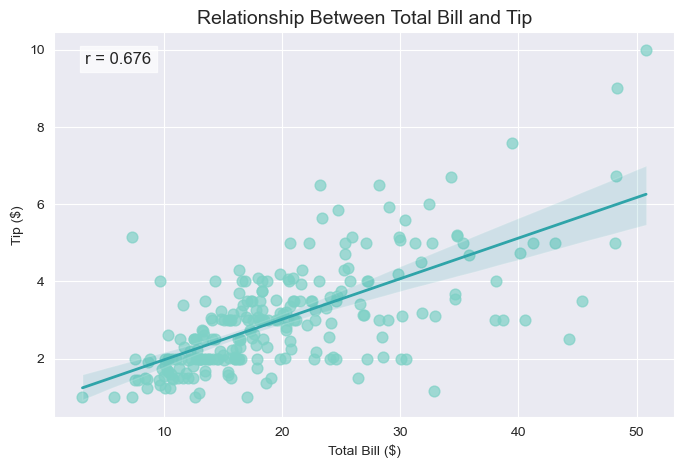

In [4]:
#Analysis between tip amount and bill amount. Do larger bills mean larger tips?

# Correlation for tip amount
corr_tip = df["total_bill"].corr(df["tip"])


sns.set_style("darkgrid")

plt.figure(figsize = (8,5))

sns.regplot(
    data = df,
    x = "total_bill",
    y = "tip",
    scatter_kws = {
        "color": "#7ED1C6", "alpha": 0.7, "s": 60 },  # plot specs
    line_kws = {
        "color": "#2FA4A9", "linewidth": 2}  #line specs
)

plt.title("Relationship Between Total Bill and Tip", fontsize = 14)
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")

plt.text(
    0.05, 0.95,
    f"r = {corr_tip:.3f}",
    transform = plt.gca().transAxes,
    fontsize = 12,
    verticalalignment = 'top',
    bbox = dict(facecolor = 'white', alpha = 0.7)
)
plt.show()

In [5]:
# Calculate tip percentage

df["tip_percentage"] = (df["tip"] / df["total_bill"]) * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_percentage
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


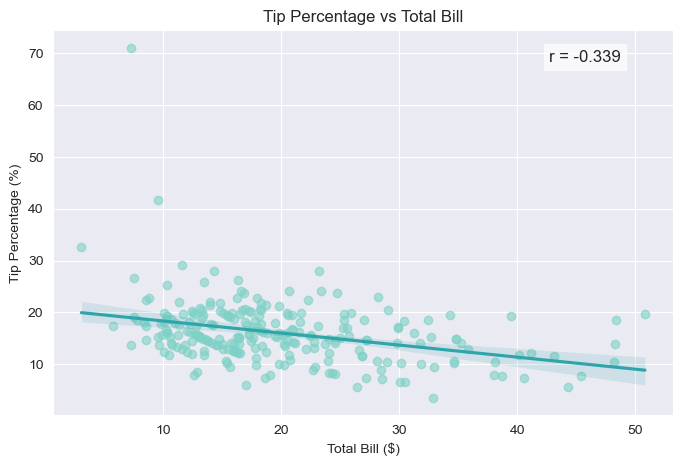

In [6]:
#Tip percentage versus bill


# Correlation for tip percentage
corr_percent = df["total_bill"].corr(df["tip_percentage"])

plt.figure(figsize = (8,5))

sns.regplot(
    data = df,
    x = "total_bill",
    y = "tip_percentage",
    scatter_kws = {"alpha": 0.6, "color": "#7ED1C6"},
    line_kws = {"color": "#2FA4A9"}
)

plt.title("Tip Percentage vs Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip Percentage (%)")

plt.text(
    0.80, 0.95,
    f"r = {corr_percent:.3f}",
    transform = plt.gca().transAxes,
    fontsize = 12,
    verticalalignment = 'top',
    bbox = dict(facecolor = 'white', alpha = 0.7)
)

plt.show()

In [7]:
print(f"Correlation (Bill vs Tip Amount): {corr_tip:.3f}")
print(f"Correlation (Bill vs Tip %): {corr_percent:.3f}")

Correlation (Bill vs Tip Amount): 0.676
Correlation (Bill vs Tip %): -0.339


The graphs show a strong positive correlation between the total bill and the tip amount (r = 0.676), meaning as the bill amount increases, so does the tip amount. This is an expected behavior, because as the amount of the bill goes up, so does the amount of which a person is "supposed" to tip. However, the graphs also show that when analyzing tip percentage, the correlation was moderately negative (r = -0.339). This suggests that customers tend to tip a smaller percentage of the total on larger bills, even though they tend to tip more as the bill increases. This also suggests that while people may tip more than they would have on a smaller bill, they're actually tipping less on larger bills.

## Party Size Versus Tip Amount

The goal of this section is to determine if a larger group is likely to tip higher than a party of a smaller size. 

In [8]:
# Count number of tables per group size
count_by_size = df["size"].value_counts().sort_index()

# Average tip % per size
avg_tip_by_size = df.groupby("size")["tip_percentage"].mean()

# Summarize
size_summary = pd.DataFrame({
    "Number of Tables": count_by_size,
    "Average Tip %": avg_tip_by_size.round(2)
})

size_summary

,Number of Tables,Average Tip %
size,,
1,4,21.73
2,156,16.57
3,38,15.22
4,37,14.59
5,5,14.15
6,4,15.62


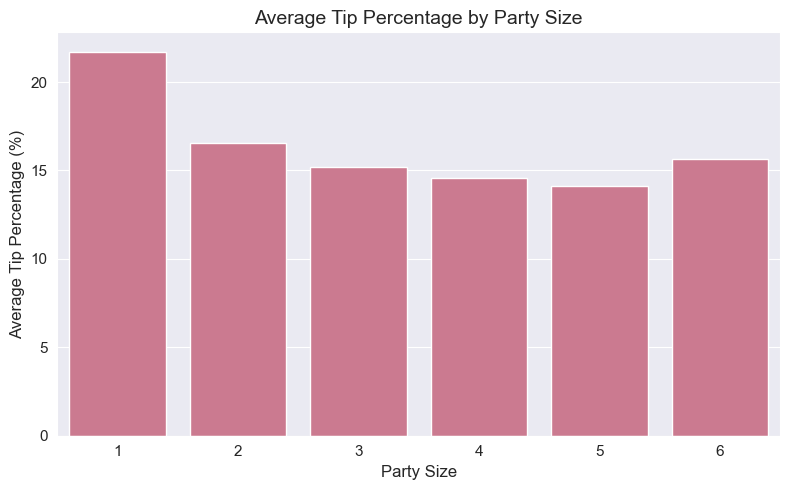

Correlation (Party Size vs Tip %): -0.143


In [9]:
sns.set_style("darkgrid")

plt.figure(figsize = (8,5))

sns.barplot(
    data = df,
    x = "size",
    y = "tip_percentage",
    color = "#D96C8A",
    errorbar = None
)

plt.title("Average Tip Percentage by Party Size", fontsize=14)
plt.xlabel("Party Size", fontsize=12)
plt.ylabel("Average Tip Percentage (%)", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

corr_size_percent = df["size"].corr(df["tip_percentage"])
print(f"Correlation (Party Size vs Tip %): {corr_size_percent:.3f}")

The bar chart shows a slight downward trend in average tip percentage as party size increases. 
Smaller tables, particularly parties of one, leave noticeably higher percentage tips, while mid-sized groups (3–5 people) tend to tip a smaller percentage of the total bill.

However, the correlation between party size and tip percentage is weak and negative (r = −0.143), indicating that group size alone does not strongly determine tipping behavior. Although larger parties generally generate higher total bills, meaning higher total tip amounts, customers appear to reduce the proportion they tip as the bill increases.

This pattern may reflect social or behavioral factors such as bill splitting, perceived affordability, or assumptions about automatic gratuity for larger groups. Overall, party size shows only a minor influence on tipping percentage compared to other variables such as total bill amount.

## Party Size Versus Bill Size

In this section, we examine how the total bill changes as party size increases.  

Understanding this relationship helps explain earlier tipping patterns. If bills increase faster than tips, it may lead to a decrease in tip percentage even when the total tip amount rises.  

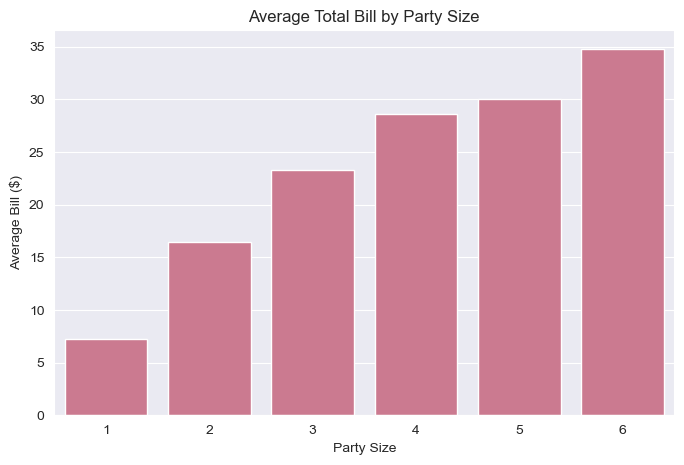

In [10]:
avg_bill_by_size = df.groupby("size")["total_bill"].mean().round(2)
avg_bill_by_size

plt.figure(figsize = (8,5))

sns.barplot(
    data = df,
    x = "size",
    y = "total_bill",
    color = "#D96C8A",
    errorbar = None
)

plt.title("Average Total Bill by Party Size")
plt.xlabel("Party Size")
plt.ylabel("Average Bill ($)")

plt.show()

In [11]:
corr_size_bill = df["size"].corr(df["total_bill"])
print("Correlation (Party Size vs Bill):", round(corr_size_bill,3))

Correlation (Party Size vs Bill): 0.598


The bar chart shows a positive relationship between party size and total bill amount. As the number of people at a table increases, the average total bill rises substantially.  
This is supported by a moderately strong positive correlation (r = 0.598), indicating that larger groups consistently spend more overall.

However, when compared to earlier findings, tip percentage does not increase at the same rate. While larger parties generate higher bills, which leads to higher tips, they tend to leave a slightly smaller percentage tip as party size grows (r = -0.143).  

Overall, although servers earn more in total tips from larger groups, tipping behavior becomes less generous relative to the bill size as group size increases. This suggests that party size has a stronger influence on bill size than it does on tip percentage. 

## Lunch Tipping Behavior Versus Dinner 

This section compares tipping behavior between the lunch and dinner service times. 
The goal is to visually evaluate whether time of day appears to influence average tip percentage.

In [12]:
df["time"].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [13]:
#Find the average (mean) of tipping for dinner and lunch colunmns
df.groupby("time")["tip_percentage"].mean().round(2)

time
Dinner    15.95
Lunch     16.41
Name: tip_percentage, dtype: float64

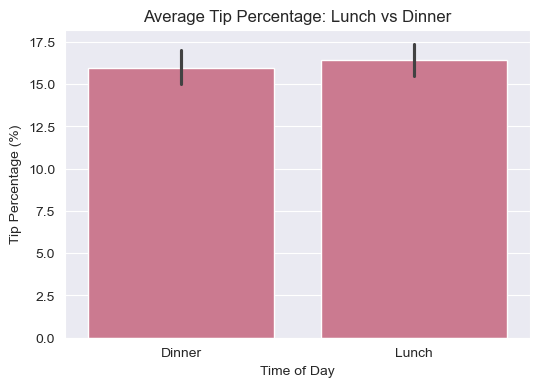

In [14]:
sns.set_style("darkgrid")

plt.figure(figsize = (6,4))

sns.barplot(
    data = df,
    x = "time",
    y = "tip_percentage",
    color = "#D96C8A"
) 

plt.title("Average Tip Percentage: Lunch vs Dinner"),
plt.xlabel("Time of Day"),
plt.ylabel("Tip Percentage (%)"),
    
        
plt.show()

The average tip percentage for lunch is slightly higher than dinner (16.41% vs 15.95%). However, the difference is small, suggesting that time of day does not strongly influence tipping behavior in this dataset. Even though most observations occur during dinner service, tipping patterns appear relatively consistent across both meal times.

## Predicting Tip Amount Using Regression

This section examines whether the total bill can be used to predict the tip amount. 
A linear regression model is used to visualize and quantify the relationship between bill size and tipping behavior.

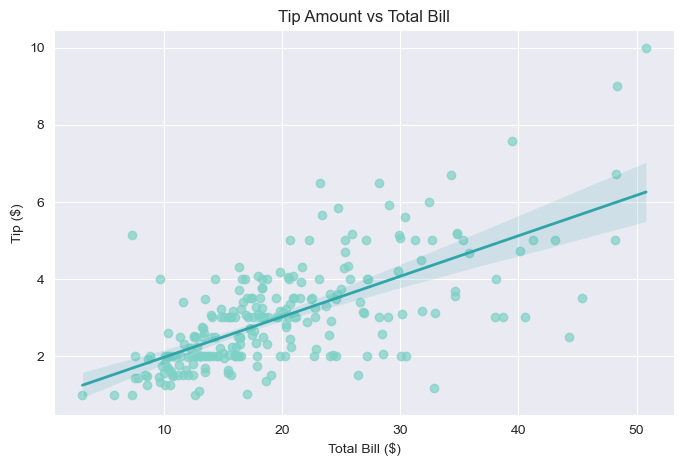

In [15]:
sns.set_style("darkgrid")

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="total_bill",
    y="tip",
    scatter_kws={"color": "#7ED1C6", "alpha": 0.7},
    line_kws={"color": "#2FA4A9", "linewidth": 2}
)

plt.title("Tip Amount vs Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")

plt.show()

In [16]:
X = df[["total_bill"]]
y = df["tip"]

model = LinearRegression()
model.fit(X,y)
model.coef_ #slope of the regression
model.intercept_ #find y int

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Slope: 0.10502451738435332
Intercept: 0.920269613554674


In [17]:
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
r2

0.45661658635167657

The regression results show a positive linear relationship between total bill and tip amount. As the total bill increases, the expected tip amount also increases.

The model explains about 45.6% of the variation in tipping behavior (R^2 = 0.456), indicating that bill size is an important but only a moderate predictor. This suggests that while larger bills generally lead to higher tips, other behavioral or contextual factors still influence tipping outcomes. 


The regression analysis confirms a positive linear relationship between total bill and tip amount. 
The model estimates that for every additional dollar spent on the bill, the expected tip increases by about 10.5 cents.

## Regression Extension Using Party Size

To improve predictive accuracy, a multiple regression model was developed by adding party size as an additional predictor alongside total bill amount. 

This extension evaluates whether including group size helps explain more variation in tip amounts compared to using bill size alone.

In [18]:
X_multi = df[["total_bill", "size"]]
y = df["tip"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y)

df[["total_bill", "size"]]
model_multi.coef_

array([0.09271334, 0.19259779])

In [19]:
#r^2
y_pred_multi = model_multi.predict(X_multi)

r2_multi = r2_score(y, y_pred_multi)

print("Multiple Regression R^2:", round(r2_multi,3))

Multiple Regression R^2: 0.468


Adding party size as an additional predictor slightly improved the model performance (R^2 increased from 0.456 to 0.468). However, the overall gain in explanatory power was small.

This suggests that much of the influence of party size on tipping behavior is already captured through its effect on total bill amount. Larger groups tend to generate higher bills, which lead to higher total tips.

Although party size has a positive independent effect on tip amount, total bill remains the dominant predictor. This indicates that spending level is the primary driver of tipping outcomes in this dataset, while group size plays a more indirect role.

## Regression Model Diagnostics

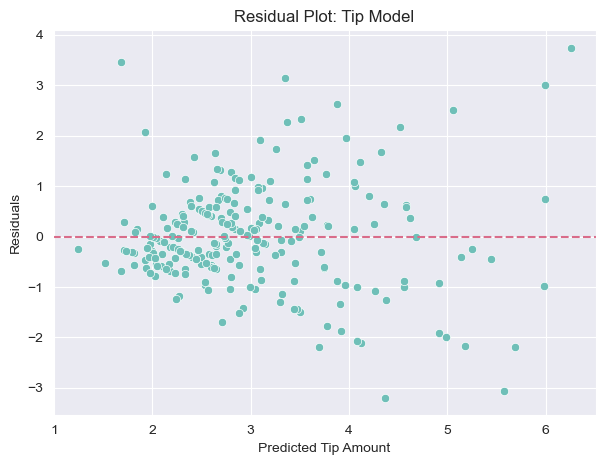

In [20]:
residuals = y - y_pred

sns.set_style("darkgrid")

plt.figure(figsize = (7,5))

sns.scatterplot(x = y_pred, y = residuals, color = "#6FBFB8")

plt.axhline(0, linestyle = "--", color = "#D96C8A")

plt.xlabel("Predicted Tip Amount")
plt.ylabel("Residuals")
plt.title("Residual Plot: Tip Model")

plt.show()

The residual plot shows that errors are generally centered around zero, suggesting that the linear model is accurate at describing the relationship between total bill and tip amount.

There is no strong curvature or pattern in the residuals, indicating that a linear form reasonably shows the underlying trend in the data. However, the spread of residuals increases slightly as predicted tip values grow. This suggests that variability in tipping behavior becomes larger for higher bill amounts.

Overall, the graphic supports the use of a linear regression model while also indicating that additional predictors or model refinements could further improve predictive performance.

## Actual vs Predicted Tip Comparison

To further evaluate the performance of the regression model, predicted tip amounts are compared with the actual observed tip values.

This visual assessment helps determine how closely the model’s predictions align with real tipping behavior and whether systematic over- or under-prediction patterns are present.

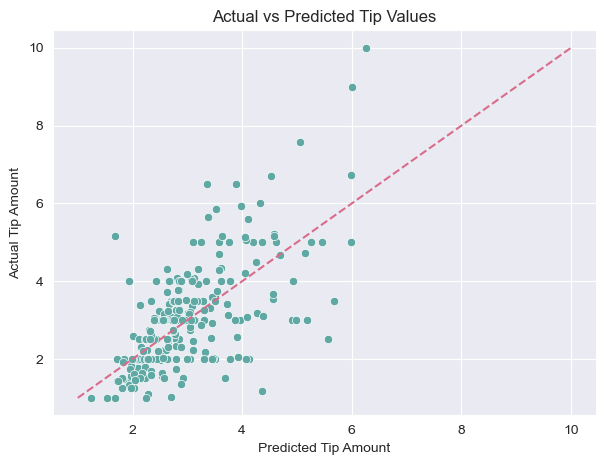

In [21]:
y_pred = model.predict(X)

sns.set_style("darkgrid")

plt.figure(figsize=(7,5))

sns.scatterplot(x = y_pred,
                y = y,
                color = "#5FA8A4")

plt.plot([y.min(), y.max()],
         [y.min(), y.max()],
         linestyle="--",
         color="#D96C8A")

plt.xlabel("Predicted Tip Amount")
plt.ylabel("Actual Tip Amount")
plt.title("Actual vs Predicted Tip Values")

plt.show()

## Overall Findings

Total bill amount emerged as the strongest predictor of tipping behavior in this dataset. Customers consistently left higher tip amounts as bill size increased, and regression analysis showed that bill size explained approximately 45.6% of the variation in tip amounts.

While larger parties contributed to higher total bills, tip percentage tends to decrease as group size increased. This suggests that tipping behavior is not directly related to total spending. Although servers earn higher total tips from larger groups, customers typically tip a smaller percentage of the total bill.

Time of day showed minimal influence on tipping patterns, with only small differences observed between lunch and dinner transactions. Overall, tipping behavior is driven more by spending level than by factors such as party size or dining period.

These results indicate that tipping outcomes are influenced by multiple external factors beyond bill size alone. Future analysis could incorporate additional predictors or multivariate modeling approaches to better explain variability in tipping behavior.

In [22]:
df.to_csv("restaurant_tips.csv", index=False)

In [23]:
import os
os.getcwd()

'/Users/makaylaf/data-portfolio/restaurant-tipping-analysis'